# The link

*One port shared by sessions through the broker: who owns the wire, who else is attached, and what a session may undo on its way out.*

**Abstract.** The board is one slave on one wire, and two masters on it split a frame. This notebook opens a session on the stand-in, and on a board with the knob flipped, and asks where it landed, who is serving the port and what the wire's own counters say; then it opens a second session, `second`, and checks what one session's close does to the other's board. The broker that shares a real port cannot serve the stand-in, which speaks methods rather than frames, so the notebook runs one in this process over a scripted wire and measures it: the attach time, a look against a use in the client count, two clients' requests interleaved whole and never overlapped, a refusal crossing as its own class, the keepalive that answers the board's 10 s deadman every 3 s, and the linger after the last client. The headline numbers: an attach in milliseconds where starting a broker costs 5.85 s, 50 requests over two clients with none wrong and none overlapped, two keepalives in 7 s of silence, and `broker.clients()` answering None in 1.0 s when nothing serves. What a reader takes to the bench: a second session is the same board through the broker and a second board on the stand-in, `close()` disarms only what it armed unless nobody else is left, and the count of who else is attached comes from the broker, never from a file.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 Where this session landed

`open()` went through `open_session`, which asks a serving broker first - a broker is the board - then probes the ports, and takes the stand-in when nothing answers. `origin` says which: `interface` is the path (`debug probe`, `RS485`, `simulated`), `label` says whether the stand-in was asked for or fallen back to, and `unit` is the node. `device.link` is the port policy this session was opened with, `auto` or `port`; the board's link subsystem is `device.board.link`. `broker.serving()` reads the address file and costs nothing; `broker.clients()` connects, and with nobody listening a loopback SYN on this bench is dropped rather than refused, so None takes the transport's whole connect timeout to say (FINDINGS 2026-09-16).

In [3]:
import time

from coaxial.comm import broker

origin = device.origin
print('interface %-10s label %-32s real %-5s unit %d'
      % (origin.interface, origin.label, origin.real, origin.unit))
print('description:', device.system.version()['description'])
print('opened with link=%r on %r at %d baud' % (device.link, device.port, device.baud))
print('board.link:', type(device.board.link).__name__)
serving = broker.serving()
print('serving:', serving)
t = time.perf_counter()
others = broker.clients()
asked_s = time.perf_counter() - t
print('clients: %s, answered in %.2f s (connect timeout %.1f s)'
      % (others, asked_s, broker.CONNECT_S))

interface simulated  label Simulated                        real False unit 1
description: SIMULATED three-phase BLDC inverter at the pelvis
opened with link='auto' on 'COM4' at 115200 baud
board.link: SimulatedLink
serving: None
clients: None, answered in 0.00 s (connect timeout 1.0 s)


None is not a count of zero: nothing is serving the stand-in, and the question cost the connect timeout to answer. Through a live broker at the bench the same call counts this session, and never itself - asking is not using.

## 3 The wire's own counters

The board has three UARTs - USART3 on the debug probe, USART2 and UART5 on RS485 through THVD1450s - and one of them carries this conversation. `port_stats` is the RTU layer's view of each: `t15_ticks` and `t35_ticks` are the Modbus character gaps in raw `DWT->CYCCNT` ticks, never microseconds (invariant 2); `bus_message` counts every frame seen on the segment and `server_message` the ones addressed to this unit, and `for_others` is the difference, which on a multidrop bus says the address filter works rather than that the wire is quiet. `loopback` has the board drive four patterns on a port and listen on its own receiver: the transceivers have RE tied to GND so all four come back, and the port carrying this link refuses in words. `echo` round-trips a payload through the link itself.

In [4]:
from coaxial.errors import DeviceStateError

link = device.board.link
ports = {port: link.port_stats(port) for port in (0, 1, 2)}
for port, stat in ports.items():
    print('%d %-7s rs485=%-5s open=%-5s %6d baud  t15 %5d  t35 %5d ticks'
          % (port, stat['name'], stat['rs485'], stat['open'], stat['baud'],
             stat['t15_ticks'], stat['t35_ticks']))
    print('  frames seen %d, for this unit %d, for others %d; comm errors %d, '
          'exceptions %d, overruns %d, dropped %d'
          % (stat['bus_message'], stat['server_message'], stat['for_others'],
             stat['bus_comm_error'], stat['server_exception'],
             stat['char_overrun'], stat['ring_dropped']))
gaps = ports[0]['t35_ticks'] / ports[0]['t15_ticks']
print('t35/t15 = %.3f, where 3.5/1.5 = %.3f' % (gaps, 3.5 / 1.5))

0 USART3  rs485=False open=True  115200 baud  t15  1750  t35  4083 ticks
  frames seen 42, for this unit 42, for others 0; comm errors 0, exceptions 0, overruns 0, dropped 0
1 USART2  rs485=True  open=True  115200 baud  t15  1750  t35  4083 ticks
  frames seen 42, for this unit 42, for others 0; comm errors 0, exceptions 0, overruns 0, dropped 0
2 UART5   rs485=True  open=True  115200 baud  t15  1750  t35  4083 ticks
  frames seen 42, for this unit 42, for others 0; comm errors 0, exceptions 0, overruns 0, dropped 0
t35/t15 = 2.333, where 3.5/1.5 = 2.333


In [5]:
loops, refused_ports = {}, []
for port in (0, 1, 2):
    try:
        loops[port] = link.loopback(port)
        print('%d %-7s matched 0x%02X, %d of 4 returned, ok=%s'
              % (port, loops[port]['name'], loops[port]['matched'],
                 loops[port]['returned'], loops[port]['ok']))
    except DeviceStateError as exc:
        refused_ports.append(port)
        print('%d refused: %s' % (port, exc))
t = time.perf_counter()
for _ in range(100):
    link.echo(b'\x00\xff\x5a\xa5')
echo_ms = 1000 * (time.perf_counter() - t) / 100
print('echo: 100 round trips, %.3f ms each' % echo_ms)

0 refused: port 0 carries this conversation; a port cannot check its own loopback while it is answering on it
1 USART2  matched 0x0F, 4 of 4 returned, ok=True
2 UART5   matched 0x0F, 4 of 4 returned, ok=True
echo: 100 round trips, 0.001 ms each


The gap ratio is the standard's, 3.5 to 1.5 character times, whatever the tick. The stand-in's echo is a method call; a board's round trip over the probe's 115200 baud is about 15 ms (FINDINGS), and that is the number a bench compares against.

## 4 A reading with the front end off

AFE_ON powers the ADC reference. Off, every channel reads exact mid-scale and the NTC exactly 25.00 C - plausible, not a measurement - so a cooked reading, one that claims a physical quantity, is refused in the board's words while raw codes still answer under a label (invariant 9). The rail is refcounted and `users` names who holds it: `daq.enable()` takes this session's own reference, which its `close()` releases, and a session that merely observed the rail on holds nothing - measured 2026-08-29, when the other holder let go and the rail dropped mid-view.

In [6]:
print('before:', device.afe.state())
try:
    device.analog.scan()
except DeviceStateError as exc:
    print('refused:', exc)
daq = device.daq
daq.open()
daq.enable()
rail = device.afe.state()
print('after enable:', rail)
scan = device.analog.scan()
print('scan: DC link %d mV, NTC %.2f C, afe_on %s'
      % (scan['dcbus_mv'], scan['ntc_centidegc'] / 100.0, scan['afe_on']))

before: {'on': False, 'pe15': True, 'users': []}
refused: the scan reports the analog front end off, so every channel read mid-scale: ntc_centidegc would be exactly 2500 and dcbus_mv a plausible number that is not a measurement. Call board.afe.on() first.
after enable: {'on': True, 'pe15': False, 'users': ['host']}
scan: DC link 24282 mV, NTC 49.28 C, afe_on True


## 5 A second session on the same port

`second` is the other session, a second `Coaxial63100` on the same port, opened here and nowhere else. On a port the first session spawned a broker in its own process and this one attaches to it over loopback, so both talk to one board; on the stand-in each open builds its own board, and `second` sees a rail this session never switched. That difference is the check: the rail `device` took, read from `second`. The stage is then armed here - at zero duty, all three low sides on, the break bypassed and the interlock ignored as the unmodified bench board needs - and `armed_here` is asked of both, since `armed()` reads the board and answers for everybody. Then `second.close()`: a close disarms what its own session armed, and otherwise only when nobody else is left, because the stage is the board's and not a session's.

In [7]:
second = Coaxial63100(port=PORT, device=SIMULATED).open()
print(second)
print('the rail, seen from second:', second.afe.state())
shared = second.afe.is_on()
print('the rail device took is visible from second:', shared)
print('clients:', broker.clients())

<Coaxial63100 Simulated SIMULATED>
the rail, seen from second: {'on': False, 'pe15': True, 'users': []}
the rail device took is visible from second: False
clients: None


In [8]:
device.gates.on(bypass_sto=True, ignore_interlock=True)
armed_here, armed_there = device.gates.armed_here, second.gates.armed_here
print('armed: device armed_here=%s armed()=%s | second armed_here=%s armed()=%s'
      % (armed_here, device.gates.is_on(), armed_there, second.gates.is_on()))
second.close()
still_armed = device.gates.is_on()
print('second closed: device armed()=%s, clients %s' % (still_armed, broker.clients()))
after = device.gates.off()
disarmed = not device.gates.is_on()
print('disarmed here: armed()=%s, break bypassed=%s' % (not disarmed, after['break_bypassed']))

armed: device armed_here=True armed()=True | second armed_here=False armed()=False
second closed: device armed()=True, clients None
disarmed here: armed()=False, break bypassed=False


On the stand-in `second.close()` cannot touch this board because there is no shared board to touch, so the stage reading is only proven at the bench; the disarm is this session's own, done before the close cell so the builder's close finds nothing to undo.

## 6 The broker, on a scripted wire

There is no simulated broker: the stand-in has no port for two processes to contend over and speaks methods rather than frames, so a broker in front of it would forward nothing. `broker.serve` takes a transport in place of the UART - the seam `test_broker.py` uses - and this section serves one in this process over a wire that stamps every request, answers after a scripted 4 ms in place of a board's reply time, and counts how many requests were inside it at once. It listens on a TCP port and an address file of its own, so a broker serving the bench is never touched. The linger is scaled from the bench's 45 s to 2 s to fit the page; the keepalive stays at 3 s, because the number under test is the firmware's.

In [9]:
import os
import tempfile
import threading

from coaxial import errors
from coaxial.comm import protocol


class Wire:
    """A transport that answers without a UART, as test_broker's does:
    every request stamped, and a count of how many were inside at once."""
    baud = 115200

    def __init__(self, delay=0.004):
        self.delay = delay              # a board's reply time, scripted
        self.calls = []
        self.inside = 0
        self.overlapped = 0

    def request(self, unit, function, payload=b'', exact_payload=None,
                timeout=None, reply_shape=None):
        self.inside += 1
        self.overlapped += self.inside > 1
        try:
            self.calls.append((time.perf_counter(), unit, function, bytes(payload)))
            time.sleep(self.delay)
            if function == 0xED:        # scripted: the board refuses this one
                raise errors.DeviceStateError('the analog front end is off')
            return bytes([unit, function]) + bytes(payload)
        finally:
            self.inside -= 1


ADDRESS = ('127.0.0.1', 8795)         # not 8763: a broker serving the bench is left alone
LINGER = 2.0                          # 45 s at the bench, scaled to fit the page
bench_address_file = broker.WHERE
broker.WHERE = os.path.join(tempfile.gettempdir(), 'coaxial_link_paper.addr')
wire = Wire()
threading.Thread(target=broker.serve, args=('WIRE', 115200, ADDRESS),
                 kwargs={'transport': wire, 'linger': LINGER}, daemon=True).start()
up = time.perf_counter()
while not broker.serving():
    time.sleep(0.01)
print('serving after %.3f s:' % (time.perf_counter() - up), broker.serving())

serving after 0.018 s: {'serial': 'WIRE', 'pid': 7716, 'kind': 'serial', 'host': '127.0.0.1', 'tcp': 8795}


A look is not a use. `--status` and the staleness check attach to prove the broker answers and close again; counted, the last one out would be whoever asked whether anybody was in. So a client joins the count on its first request, and `clients()` reads 0 after an attach and 1 after a frame.

In [10]:
t = time.perf_counter()
client_1 = broker.attach(ADDRESS)
attach_ms = 1000 * (time.perf_counter() - t)
print('attached in %.1f ms to %r at %d baud' % (attach_ms, client_1.port, client_1.baud))
looked = broker.clients(ADDRESS)
print('clients after a look:', looked)
print('a request crosses:', client_1.request(1, protocol.VERSION, b'\x01').hex(' '))
used = broker.clients(ADDRESS)
print('clients after a use:', used)
client_2 = broker.attach(ADDRESS)
client_2.request(2, protocol.VERSION, b'\x02')
both = broker.clients(ADDRESS)
print('clients with two using:', both)

attached in 1.3 ms to 'WIRE' at 115200 baud
clients after a look: 0
a request crosses: 01 41 01
clients after a use: 1
clients with two using: 2


The lock is the whole design. Two clients fire 25 requests each from two threads; the wire records who was inside it and when, and every reply is checked against the client that asked.

In [11]:
before = len(wire.calls)
wrong = []


def hammer(client, tag):
    for _ in range(25):
        got = client.request(tag, protocol.VERSION, bytes([tag]))
        if got != bytes([tag, protocol.VERSION, tag]):
            wrong.append((tag, got.hex()))


threads = [threading.Thread(target=hammer, args=(client, tag))
           for tag, client in ((1, client_1), (2, client_2))]
t = time.perf_counter()
for thread in threads:
    thread.start()
for thread in threads:
    thread.join()
hammer_s = time.perf_counter() - t
crossed = wire.calls[before:]
print('%d requests over two clients in %.3f s = %.1f ms each; %d wrong; '
      'inside the wire together %d times'
      % (len(crossed), hammer_s, 1000 * hammer_s / len(crossed), len(wrong),
         wire.overlapped))
print('order on the wire:', ''.join(str(unit) for _, unit, _, _ in crossed))
crossed_as = 'no refusal'
try:
    client_1.request(1, 0xED)
except errors.RigError as exc:
    crossed_as = type(exc).__name__
    print('a refusal crossed as %s: %s' % (crossed_as, exc))

50 requests over two clients in 0.218 s = 4.4 ms each; 0 wrong; inside the wire together 0 times
order on the wire: 12121212121212121212121212121212121212121212121212
a refusal crossed as DeviceStateError: the analog front end is off


The firmware drops a silent host's rail claims and its armed stage after 10 s (`BOARD_POWER_HOST_QUIET_MS`) - right for a killed script, wrong for an operator thinking between turns. The broker speaks for an attached client after 3 s of quiet, a third of that, and only while somebody is attached. The keepalive is a timer on silence, so the measurement is 7 s of it: long enough for two ticks, short of the deadman. Then the last client leaves, and the linger is timed until nothing answers; the address file a killed broker leaves behind is written back by hand, to show what a stale one costs.

In [12]:
import json

client_2.close()
one_left = broker.clients(ADDRESS)
print('clients after one closed:', one_left)
quiet_from = time.perf_counter()
heard = len(wire.calls)
QUIET = 7.0                     # two 3 s keepalives, under the 10 s deadman
time.sleep(QUIET)
ticks = [stamp - quiet_from for stamp, unit, function, payload in wire.calls[heard:]
         if function == protocol.VERSION and not payload]
print('%d keepalives in %.0f s of silence, at %s s'
      % (len(ticks), QUIET, ', '.join('%.2f' % s for s in ticks)))
left_at = time.perf_counter()
client_1.close()
probe = broker.attach(ADDRESS, timeout=0.3)
while probe is not None:
    probe.close()
    time.sleep(0.05)
    probe = broker.attach(ADDRESS, timeout=0.3)
down_at = time.perf_counter()
print('nothing answers %.2f s after the last client left; the linger is %.1f s here, 45 s at the bench'
      % (down_at - left_at, LINGER))
print('address file after stand-down:', broker.serving())
with open(broker.WHERE, 'w', encoding='utf-8') as handle:     # what a killed broker leaves
    json.dump({'serial': 'WIRE', 'pid': 0, 'host': ADDRESS[0], 'tcp': ADDRESS[1]}, handle)
t = time.perf_counter()
stale = broker.serving()['serial'], broker.attach(ADDRESS, timeout=0.5)
stale_s = time.perf_counter() - t
print('a stale file names %r; attaching answers %s in %.2f s' % (stale[0], stale[1], stale_s))
os.remove(broker.WHERE)
broker.WHERE = bench_address_file

clients after one closed: 1


2 keepalives in 7 s of silence, at 3.29, 6.35 s


nothing answers 2.03 s after the last client left; the linger is 2.0 s here, 45 s at the bench
address file after stand-down: None


a stale file names 'WIRE'; attaching answers None in 1.03 s


Who spoke on the wire, and when: the two clients' requests alternating, the silence, the broker's own two frames in it, and the linger with nobody attached.

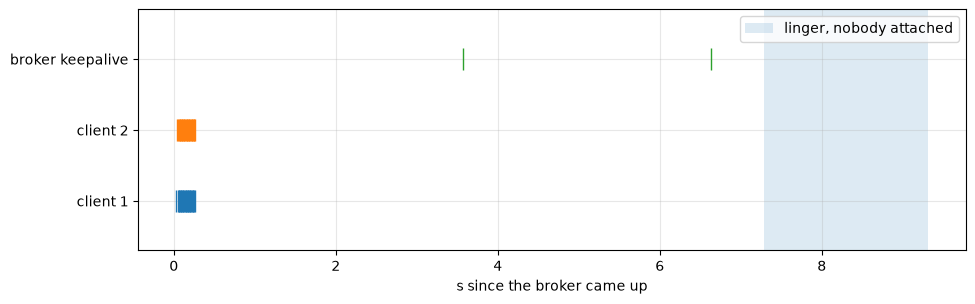

In [13]:
from coaxial.draw.figures import figure, show

fig, (panel,) = figure(rows=1)
lanes = (('client 1', lambda unit, function, payload: payload and unit == 1),
         ('client 2', lambda unit, function, payload: payload and unit == 2),
         ('broker keepalive',
          lambda unit, function, payload: function == protocol.VERSION and not payload))
for lane, (label, mine) in enumerate(lanes):
    stamps = [stamp - up for stamp, unit, function, payload in wire.calls
              if mine(unit, function, payload)]
    panel.plot(stamps, [lane] * len(stamps), '|', markersize=16)
panel.axvspan(left_at - up, down_at - up, alpha=0.15, label='linger, nobody attached')
panel.set_yticks(range(len(lanes)))
panel.set_yticklabels([label for label, _ in lanes])
panel.set_ylim(-0.7, len(lanes) - 0.3)
panel.set_xlabel('s since the broker came up')
panel.legend(loc='upper right')
show(fig)

In [14]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 7 Conclusions

In [15]:
print('1. session   %s (%s); link=%r on %r; serving %s; clients %s, answered in %.2f s'
      % (origin.interface, origin.label, device.link, device.port, serving, others, asked_s))
print('2. wire      t15 %d, t35 %d ticks, t35/t15 %.3f; %d frames seen, %d for this unit, '
      '%d for others, %d comm errors; loopback ok on ports %s, refused on %s; echo %.3f ms a round trip'
      % (ports[0]['t15_ticks'], ports[0]['t35_ticks'], gaps, ports[0]['bus_message'],
         ports[0]['server_message'], ports[0]['for_others'], ports[0]['bus_comm_error'],
         sorted(p for p, loop in loops.items() if loop['ok']), refused_ports, echo_ms))
print('3. front end refused while off; users after enable %s; DC link %d mV, NTC %.2f C once on'
      % (rail['users'], scan['dcbus_mv'], scan['ntc_centidegc'] / 100.0))
print('4. sessions  the rail device took, seen from second: %s; armed here %s, armed_here from second %s; '
      'still armed after second closed %s; disarmed here %s'
      % (shared, armed_here, armed_there, still_armed, disarmed))
print('5. broker    attached in %.1f ms; clients after a look %d, a use %d, two %d, one closed %d; '
      '%d requests %.1f ms each, %d wrong, %d overlapped; a refusal crossed as %s'
      % (attach_ms, looked, used, both, one_left, len(crossed),
         1000 * hammer_s / len(crossed), len(wrong), wire.overlapped, crossed_as))
print('6. timers    %d keepalives in %.0f s of silence at %s s (3 s apart, under the 10 s deadman); '
      'down %.2f s after the last client at a %.1f s linger; a stale file named %r and attaching '
      'answered %s in %.2f s'
      % (len(ticks), QUIET, ', '.join('%.2f' % s for s in ticks), down_at - left_at, LINGER,
         stale[0], stale[1], stale_s))

1. session   simulated (Simulated); link='auto' on 'COM4'; serving None; clients None, answered in 0.00 s
2. wire      t15 1750, t35 4083 ticks, t35/t15 2.333; 42 frames seen, 42 for this unit, 0 for others, 0 comm errors; loopback ok on ports [1, 2], refused on [0]; echo 0.001 ms a round trip
3. front end refused while off; users after enable ['host']; DC link 24282 mV, NTC 49.28 C once on
4. sessions  the rail device took, seen from second: False; armed here True, armed_here from second False; still armed after second closed True; disarmed here True
5. broker    attached in 1.3 ms; clients after a look 0, a use 1, two 2, one closed 1; 50 requests 4.4 ms each, 0 wrong, 0 overlapped; a refusal crossed as DeviceStateError
6. timers    2 keepalives in 7 s of silence at 3.29, 6.35 s (3 s apart, under the 10 s deadman); down 2.03 s after the last client at a 2.0 s linger; a stale file named 'WIRE' and attaching answered None in 1.03 s


The first session on a real port spawns a broker in its own process (`tools/target/session.py`) and every later one attaches to it on loopback port 8763. The broker owns the port and hands the console over once - the board boots into its text console, and the escape cannot go into a link that is already framed - then forwards Modbus requests unchanged, unit, function and payload, holding no state of its own so it cannot become a second protocol. A refusal arrives at the client as the same `coaxial.errors` class it would have raised in-process, carrying the board's own sentence: invariant 8 does not stop at a socket. One lock is the whole design, since the board is one slave on one wire, and the 50 requests above crossed whole and alternated, never two inside the transport at once. Opening through a live broker is 0.05 s against 5.85 s starting one, which is why it lingers 45 s after the last client (FINDINGS 2026-08-29); the attach measured here is the loopback's share of that.

The broker answers the board's 10 s deadman every 3 s for an attached client, and only then: the firmware drops a silent host's rail claims and its armed stage after `BOARD_POWER_HOST_QUIET_MS` (`board_power.c`), and the keepalive is what keeps a session thinking between turns from losing what it holds. The stage is the board's, not a session's: `close()` disarms what this session armed, and otherwise only when nobody else is left - three switching runs once ended the moment a second session asked the board an unrelated question (FINDINGS 2026-08-29). `broker.clients()` is None when nothing is serving the port: asking is not using, so the count it reports attaches, asks and closes, and does not include itself; and a connect to a loopback port nobody listens on is not refused on this bench but waits out its timeout, which is why the transport connects on `CONNECT_S` of one second and a stand-in never asks.

**At the bench.** Flip `SIMULATED` and name the port. Section 2 then says which path the session took - the debug probe, RS485, or a broker already serving - and `python tools/target/session.py --status` says who else is on it. Compare conclusion 2's t35/t15 against 2.33 (the standard's 3.5 over 1.5 characters) and its comm errors against zero after a minute of traffic; errors that climb are a termination or a baud problem before they are a firmware one. Open the second session from another terminal rather than this notebook, and watch conclusion 4: with two sessions the stage stays armed until the last one leaves. The broker section ran on a scripted wire in this process; at the bench the same numbers come from the real one - the attach off `--status`, the keepalive off gate op 0's count, the linger by leaving and asking again after 45 s. What the stand-in could not show: a real port refusing a second opener, the console handover on a board that boots into its text console, and a deadman actually dropping a rail.

## References

* `host/coaxial/comm/session.py` - `open_session`: a serving broker first, then the ports, then the stand-in
* `host/coaxial/comm/broker.py` - the broker: one lock, the keepalive, `clients()`, `attach` on `CONNECT_S`
* `host/tools/target/session.py` - spawns a broker for a port and reports who is attached
* `host/coaxial/rig.py` - `close()`: what a session disarms, and when
* `comms/src/cmd_link.c` - echo and the counters, per port
* `board/src/board_power.c` - the deadman: a silent host loses its claims after `BOARD_POWER_HOST_QUIET_MS`
* `host/tests/test_broker.py` - the broker pinned on a scripted port, no board